# Notebook 1 — Setup, Data Loading & Exploration
**Project**: Real-Time Retail Analytics & Demand Prediction Platform  
**Author**: Vineet Joshi | ZDA25M007 | IIT Madras Zanzibar  
**Stack**: JupyterLab | Pandas | MinIO (`retail-v2/`)  

This notebook loads the Online Retail II dataset, cleans it, performs EDA, and saves a clean version.

---

## 1.1 Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install deltalake pyarrow boto3 kafka-python matplotlib seaborn tqdm -q
print('Dependencies installed.')

Dependencies installed.


## 1.2 Load Raw Dataset

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '/home/jovyan/work/online_retail_II.csv'

df_raw = pd.read_csv(DATA_PATH, encoding='unicode_escape')
print(f'Raw dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Raw dataset loaded: 1,067,371 rows × 8 columns
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


## 1.3 Data Profiling

In [3]:
print('=== Data Types ===')
print(df_raw.dtypes)
print(f'\n=== Shape: {df_raw.shape} ===')
print(f'\n=== Missing Values ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Pct': missing_pct})[missing > 0])
print(f'\n=== Numeric Summary ===')
df_raw.describe()

=== Data Types ===
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

=== Shape: (1067371, 8) ===

=== Missing Values ===
              Count    Pct
Description    4382   0.41
Customer ID  243007  22.77

=== Numeric Summary ===


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


## 1.4 Rename Columns (standardize)

In [4]:
# Standardize column names based on proposal
col_mapping = {
    'Invoice':     'InvoiceNo',
    'Price':       'UnitPrice',
    'Customer ID': 'CustomerID'
}
# Only rename columns that exist
rename_map = {k: v for k, v in col_mapping.items() if k in df_raw.columns}
df = df_raw.rename(columns=rename_map).copy()
print(f'Columns after rename: {df.columns.tolist()}')

Columns after rename: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 1.5 Data Cleaning

In [5]:
print(f'Before cleaning: {len(df):,} rows')

# Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Drop rows with missing critical fields
df = df.dropna(subset=['InvoiceDate'])

# Convert numeric columns
df['Quantity']   = pd.to_numeric(df['Quantity'],   errors='coerce')
df['UnitPrice']  = pd.to_numeric(df['UnitPrice'],  errors='coerce')

# Filter: positive quantity and price only
df = df[df['Quantity']  > 0]
df = df[df['UnitPrice'] > 0]

# Handle CustomerID
if 'CustomerID' in df.columns:
    df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce')
    df = df.dropna(subset=['CustomerID'])
    df['CustomerID'] = df['CustomerID'].astype(int)

# Compute Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Reset index
df = df.reset_index(drop=True)

print(f'After cleaning:  {len(df):,} rows')
print(f'Removed:         {len(df_raw) - len(df):,} rows ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)')

Before cleaning: 1,067,371 rows
After cleaning:  805,549 rows
Removed:         261,822 rows (24.5%)


## 1.6 Exploratory Data Analysis

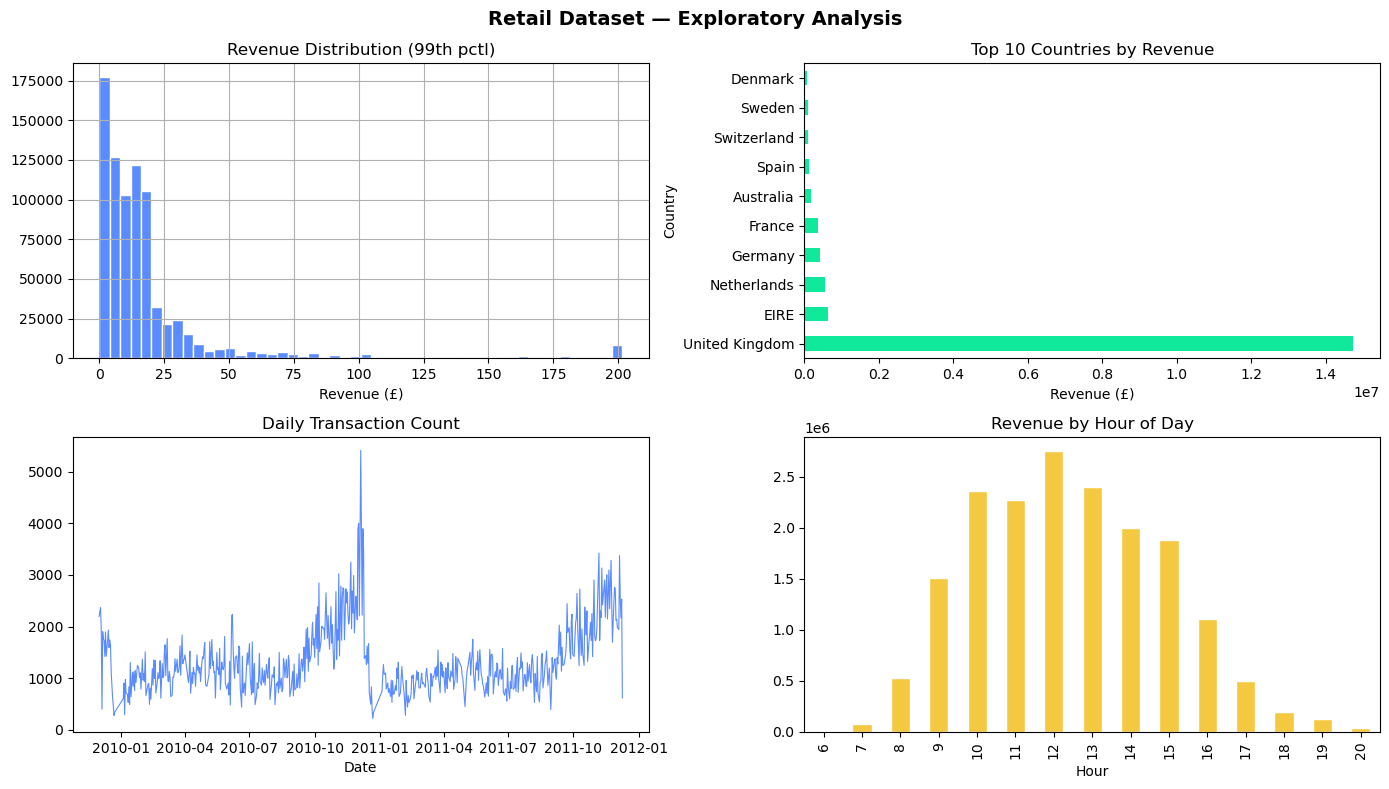

EDA plots saved to eda_plots.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Retail Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

# 1. Revenue distribution
df['Revenue'].clip(upper=df['Revenue'].quantile(0.99)).hist(bins=50, ax=axes[0,0], color='#5b8cff', edgecolor='white')
axes[0,0].set_title('Revenue Distribution (99th pctl)')
axes[0,0].set_xlabel('Revenue (£)')

# 2. Top 10 countries by revenue
top_countries = df.groupby('Country')['Revenue'].sum().nlargest(10)
top_countries.plot(kind='barh', ax=axes[0,1], color='#10e89b')
axes[0,1].set_title('Top 10 Countries by Revenue')
axes[0,1].set_xlabel('Revenue (£)')

# 3. Daily transaction count
daily_tx = df.groupby(df['InvoiceDate'].dt.date).size()
daily_tx.plot(ax=axes[1,0], color='#5b8cff', linewidth=0.8)
axes[1,0].set_title('Daily Transaction Count')
axes[1,0].set_xlabel('Date')

# 4. Hourly sales pattern
hourly = df.groupby(df['InvoiceDate'].dt.hour)['Revenue'].sum()
hourly.plot(kind='bar', ax=axes[1,1], color='#f5c842', edgecolor='white')
axes[1,1].set_title('Revenue by Hour of Day')
axes[1,1].set_xlabel('Hour')

plt.tight_layout()
plt.savefig('/home/jovyan/work/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved to eda_plots.png')

In [7]:
# Key statistics
print('='*50)
print('DATASET SUMMARY')
print('='*50)
print(f'Date range     : {df["InvoiceDate"].min()} → {df["InvoiceDate"].max()}')
print(f'Total records  : {len(df):,}')
print(f'Total revenue  : £{df["Revenue"].sum():,.2f}')
print(f'Unique invoices: {df["InvoiceNo"].nunique():,}')
print(f'Unique products: {df["StockCode"].nunique():,}')
if 'CustomerID' in df.columns:
    print(f'Unique customers: {df["CustomerID"].nunique():,}')
print(f'Countries      : {df["Country"].nunique()}')
print(f'Avg order value: £{df["Revenue"].sum() / df["InvoiceNo"].nunique():.2f}')

DATASET SUMMARY
Date range     : 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Total records  : 805,549
Total revenue  : £17,743,429.18
Unique invoices: 36,969
Unique products: 4,631
Unique customers: 5,878
Countries      : 41
Avg order value: £479.95


## 1.7 Save Clean Dataset

In [8]:
CLEAN_PATH = '/home/jovyan/work/retail_clean.parquet'
df.to_parquet(CLEAN_PATH, index=False)
print(f'Clean dataset saved: {CLEAN_PATH}')
print(f'Rows: {len(df):,}')

Clean dataset saved: /home/jovyan/work/retail_clean.parquet
Rows: 805,549


## 1.8 Create MinIO Bucket for Project

In [9]:
import boto3
from botocore.exceptions import ClientError

s3 = boto3.client(
    's3',
    endpoint_url='http://minio:9000',
    aws_access_key_id='admin',
    aws_secret_access_key='bigdata123'
)

BUCKET = 'retail-v2'

try:
    s3.create_bucket(Bucket=BUCKET)
    print(f'✅ Bucket \'{BUCKET}\' created in MinIO.')
except ClientError as e:
    code = e.response['Error']['Code']
    if code in ['BucketAlreadyOwnedByYou', 'BucketAlreadyExists']:
        print(f'Bucket \'{BUCKET}\' already exists — OK.')
    else:
        raise

print(f'\nAll buckets:')
for b in s3.list_buckets()['Buckets']:
    print(f'  • {b["Name"]}')

Bucket 'retail-v2' already exists — OK.

All buckets:
  • kafka-connect
  • mlflow-artifacts
  • retail-v2
  • warehouse


## 1.9 Summary

| Step | Status |
|------|--------|
| Load CSV | ✅ |
| Clean & filter | ✅ |
| EDA plots | ✅ |
| Save clean parquet | ✅ |
| Create MinIO bucket `retail-v2` | ✅ |

**Next**: Notebook 2 — Scale dataset to 20 million records